# Analisis de Vivienda - Los Rios
* Traducir comuna codigo a nombre
* Leer y filtrar datos
* Mostrar dataframae
* Exportar `muestra.csv`
* Mostrar grafico: % hacinamiento por comuna

# Importar librerías y mappear comunas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Mapa comunas
anexo = pd.read_excel('Libro_de_codigos_Casen_2024_prov_comuna.xlsx', sheet_name='Anexo1', skiprows=2)
anexo.columns = anexo.columns.str.strip().str.lower()
mapa = dict(zip(anexo['código comuna'], anexo['nombre comuna']))

# Extraer y filtrar los datos

In [2]:

# Datos
casen = pd.read_stata(
    'casen_2024.dta',
    columns=['folio','id_persona','region','pobreza_multi_2015','hh_d_hacina_2015'],
    convert_categoricals=False # es para evitar que panda convierta 1/0 a Si/No
)
geo = pd.read_stata(
    'casen_2024_provincia_comuna.dta',
    columns=['folio', 'id_persona', 'comuna'],
    convert_categoricals=False # lo mismo, es para mappearlos a mano y evitar errores
)

df = casen.merge(geo, on=['folio', 'id_persona'])

# Filtro
df = df[df['region'] == 14] # se queda con las filas solo donde df['region'] == 14 sea True)
hogares_distintos = df.drop_duplicates(subset='folio') # con esto evitas duplicación de información (a causa de personas > 1 en los hogares)



# Mostrar Dataframe

In [3]:

hogares_distintos.head()

,folio,id_persona,region,pobreza_multi_2015,hh_d_hacina_2015,comuna
127,100390101,1,14,0.0,0.0,14107
129,100390201,1,14,0.0,0.0,14107
133,100390301,1,14,0.0,0.0,14107
137,100390401,1,14,0.0,0.0,14107
141,100390601,1,14,0.0,0.0,14107


# Total de personas encuestadas + Hogares distintos

In [4]:
print(f"Total personas encuestadaas: {len(df)}")
print(f"Hogares distintos: {len(hogares_distintos)}")

Total personas encuestadaas: 9167
Hogares distintos: 3433


# Exportar CSV

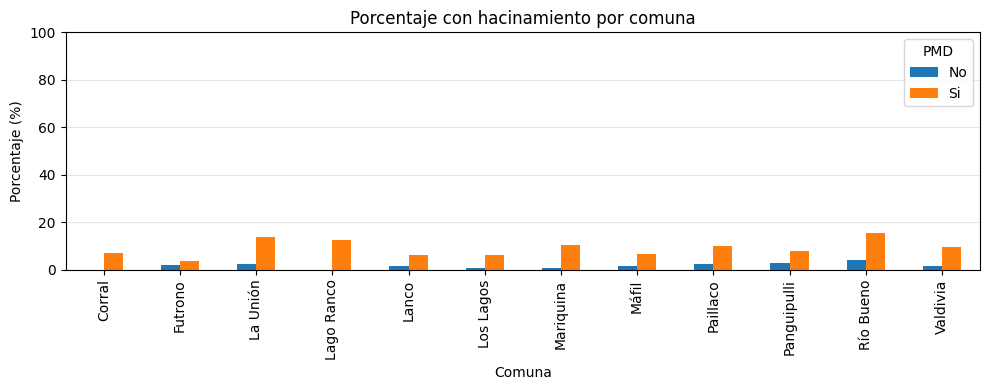

In [ ]:
# Agregar comuna_nombre al dataframe mappeandola con el diccionario que ya tenemos
hogares_distintos['comuna_nombre'] = hogares_distintos['comuna'].map(mapa)

# Exportar a CSV
cols = ['folio','id_persona','region','comuna','comuna_nombre','pobreza_multi_2015','hh_d_hacina_2015']
df_csv = hogares_distintos[cols].to_csv('muestra.csv', index=False)


# Cargar CSV y graficar

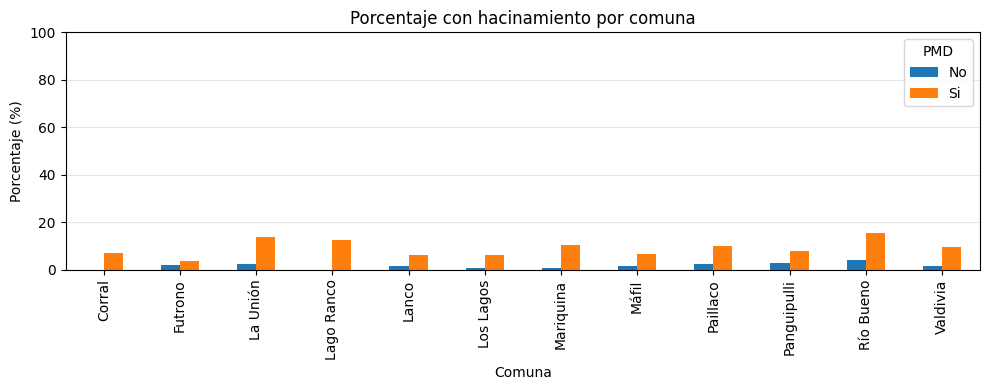

In [ ]:
# Cargar CSV
df_csv = pd.read_csv("muestra.csv")

# Asegurar tipos numéricos (por si vienen como string)
df_csv["pobreza_multi_2015"] = pd.to_numeric(df_csv["pobreza_multi_2015"])
df_csv["hh_d_hacina_2015"] = pd.to_numeric(df_csv["hh_d_hacina_2015"])

# Calcular porcentaje de hacinamiento por comuna y PMD
df_graficar = (df_csv.groupby(["comuna_nombre", "pobreza_multi_2015"])["hh_d_hacina_2015"].mean().mul(100))
# queda: Comuna, PMD - Proporción

df_graficar = df_graficar.unstack() # queda: Comuna No(ratio) Si(ratio)

# Graficar
grafico = df_graficar[[0.0, 1.0]].plot(kind="bar", figsize=(10, 4))
grafico.grid(True, axis="y")
grafico.legend(["No", "Si"], title="PMD")
plt.title("Porcentaje con hacinamiento por comuna")
plt.xlabel("Comuna")
plt.ylabel("Porcentaje (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()